In [78]:
# import all necessary objects and methods for quantum circuits
from qiskit import QuantumRegister, ClassicalRegister, QuantumCircuit, execute, Aer
from random import randrange
no_qubits=int(input("Enter the number of qubits="))
def print_outcomes_in_reserve(counts): # takes a dictionary variable
    for outcome in counts: # for each key-value in dictionary
        reverse_outcome = ''
        for i in outcome: # each string can be considered as a list of characters
            reverse_outcome = i + reverse_outcome # each new symbol comes before the old symbol(s)
    return reverse_outcome

#Source for SendState: awards/teach_me_qiskit_2018/cryptography/Cryptography.ipynb

def SendState(qc1, qc2, qc1_name):
    ''' This function takes the output of a circuit qc1 (made up only of x and 
        h gates and initializes another circuit qc2 with the same state
    ''' 
    
    # Quantum state is retrieved from qasm code of qc1
    qs = qc1.qasm().split(sep=';')[4:-1]

    # Process the code to get the instructions
    for index, instruction in enumerate(qs):
        qs[index] = instruction.lstrip()

    for instruction in qs:
        if instruction[0] == 'x':
            if instruction[5] == '[':
                old_qr = int(instruction[6:-1])
            else:
                old_qr = int(instruction[5:-1])
            qc2.x(qreg[old_qr])
        elif instruction[0] == 'h':
            if instruction[5] == '[':
                old_qr = int(instruction[6:-1])
            else:
                old_qr = int(instruction[5:-1])
            qc2.h(qreg[old_qr])
        elif instruction[0] == 'm': # exclude measuring:
            pass
        else:
            raise Exception('Unable to parse instruction')

Enter the number of qubits= 12


In [79]:
qreg = QuantumRegister(no_qubits) # quantum register with 8 qubits
creg = ClassicalRegister(no_qubits) # classical register with 8 bits

# Quantum circuit for Asja state
Alice_circuit = QuantumCircuit(qreg, creg, name='Alice')

Alice_send=[] #Initial bit string to send

#Creating random bit string
for i in range(no_qubits):
    bit = randrange(2)
    Alice_send.append(bit)
    if bit==1:
            Alice_circuit.x(qreg[i])  
   
# mesaure
print(qreg,creg)    
#Apply X gate if bit is equal to 1
'''for i, n in enumerate(Alice_send):
    if n==1:
        Alice_circuit.x(qreg[i]) # apply x-gate'''

send_str = ''.join(str(e) for e in Alice_send)

    

QuantumRegister(12, 'q61') ClassicalRegister(12, 'c21')


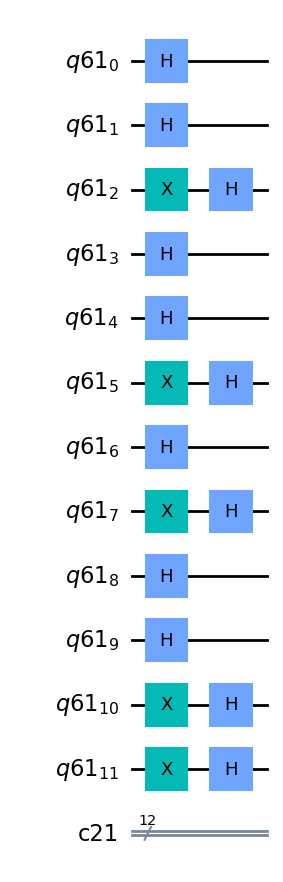

In [80]:
 
Alice_circuit.h(qreg)
display(Alice_circuit.draw('mpl'))

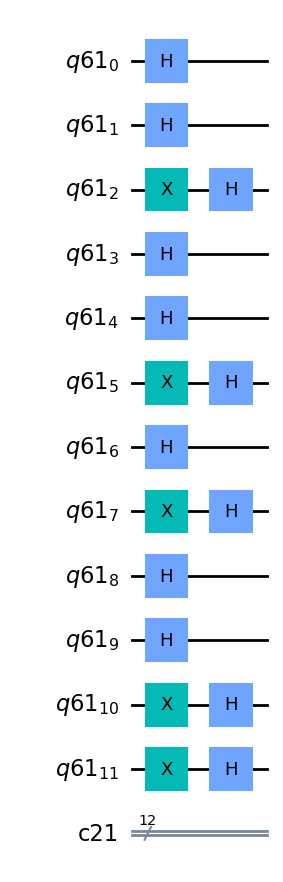

In [81]:
Bob_circuit = QuantumCircuit(qreg, creg, name='Bob') #Defining Balvis circuit
SendState(Alice_circuit, Bob_circuit, 'Alice') #Alice sends states to Bob
display(Bob_circuit.draw('mpl'))

In [82]:
Bob_circuit.h(qreg) #Applying H gate first
Bob_circuit.measure(qreg,creg) #then continue with regular measurement

job = execute(Bob_circuit,Aer.get_backend('qasm_simulator'),shots=1) #Note that Balvis only has one shot to measure qubits
counts = job.result().get_counts(Bob_circuit) # counts is a dictionary object in python
received = print_outcomes_in_reserve(counts)

print("Alice sent:", send_str)
print("Bob received:", received)


Alice sent: 001001010011
Bob received: 001001010011
